## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
! git clone https://github.com/smerashanmugan/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 43 (delta 13), reused 6 (delta 6), pack-reused 26 (from 2)
Receiving objects: 100% (43/43), 122.17 KiB | 2.30 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Download complete
Extracting data files...
Data extracted


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/golub.csv")

print(df.columns)
print(df['cancer'].unique())

df['target'] = df['cancer'].replace({
    'ALLB': 0,
    'ALLT': 0,
    'ALL': 1
})
print(df[['cancer', 'target']].head())


Index(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer',
       'AFFX-BioB-5_at', 'AFFX-BioB-M_at', 'AFFX-BioB-3_at', 'AFFX-BioC-5_at',
       ...
       'U48730_at', 'U58516_at', 'U73738_at', 'X06956_at', 'X16699_at',
       'X83863_at', 'Z17240_at', 'L49218_f_at', 'M71243_f_at', 'Z78285_f_at'],
      dtype='object', length=7135)
['allB' 'allT' 'aml']
  cancer target
0   allB   allB
1   allB   allB
2   allB   allB
3   allB   allB
4   allB   allB


Shape: (72, 7136)
Target counts:
 target
0    47
1    25
Name: count, dtype: int64
X shape: (72, 7129)
y unique: [0 1]
Training MSE: 1.2522824482837894e-30


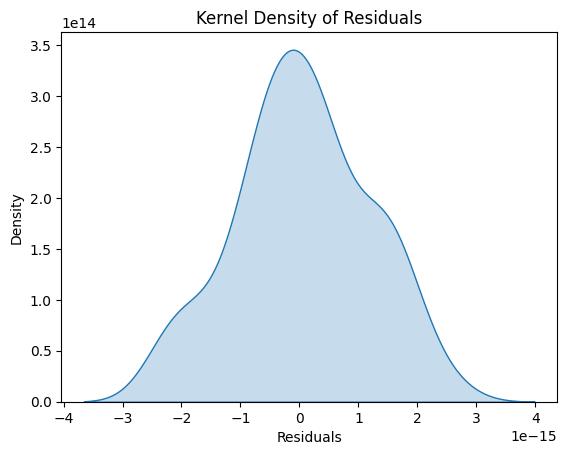

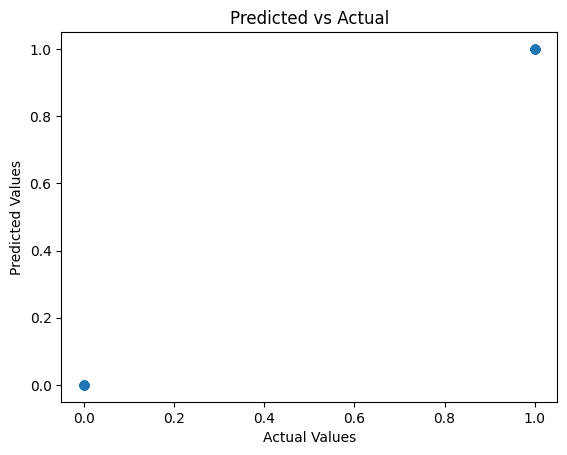

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


df = pd.read_csv("./data/golub.csv")


df['cancer'] = df['cancer'].str.upper()

mapping = {
    'ALLB': 0,
    'ALLT': 0,
    'ALL': 0,
    'AML': 1
}

df['target'] = df['cancer'].map(mapping).astype(int)


print("Shape:", df.shape)
print("Target counts:\n", df['target'].value_counts())


X = df.drop(columns=[
    'Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target'
])

y = df['target']

print("X shape:", X.shape)
print("y unique:", y.unique())


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)


mse = mean_squared_error(y, y_pred)
print("Training MSE:", mse)


residuals = y - y_pred


sns.kdeplot(residuals, fill=True)
plt.title("Kernel Density of Residuals")
plt.xlabel("Residuals")
plt.show()


plt.scatter(y, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

In [18]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np


model = LinearRegression()


kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_mse = -cross_val_score(
    model,
    X,
    y,
    scoring='neg_mean_squared_error',
    cv=kf
)


print("Cross-validated MSE (each fold):")
print(cv_mse)

print("\nAverage CV MSE:", np.mean(cv_mse))

Cross-validated MSE (each fold):
[0.0459653  0.04231634 0.04823094 0.07943783 0.01576511 0.07586618
 0.06668908 0.03873804 0.01877966 0.02787012]

Average CV MSE: 0.04596585937931276


LASSO Training MSE: 0.01013270450745053

Selected genes:
HG3549-HT3751_at   -1.665457e-06
J04164_at          -2.365289e-06
L38941_at           1.393972e-07
M11147_at           1.188055e-06
M11722_at          -1.031806e-06
M17733_at          -3.475753e-06
M19507_at           1.145890e-05
M26602_at          -2.429779e-06
M27891_at           1.005144e-05
M33680_at          -4.012150e-07
M63138_at           1.131478e-05
M91036_rna1_at      2.688857e-06
M96326_rna1_at      3.038416e-06
U14968_at           1.119254e-06
X17042_at           8.523369e-06
X78992_at           2.790669e-06
Z70759_at           9.260274e-07
L06797_s_at        -2.513142e-06
D49824_s_at        -3.685815e-07
M25079_s_at         3.296609e-07
X57351_s_at        -1.425600e-06
V00594_s_at        -1.014731e-06
U05255_s_at         1.060812e-05
X03689_s_at        -8.596225e-07
M14328_s_at         1.232427e-06
M14483_rna1_s_at   -2.327117e-06
Y00787_s_at         5.464275e-06
Z19554_s_at         5.217561e-07
X56681_s_at        

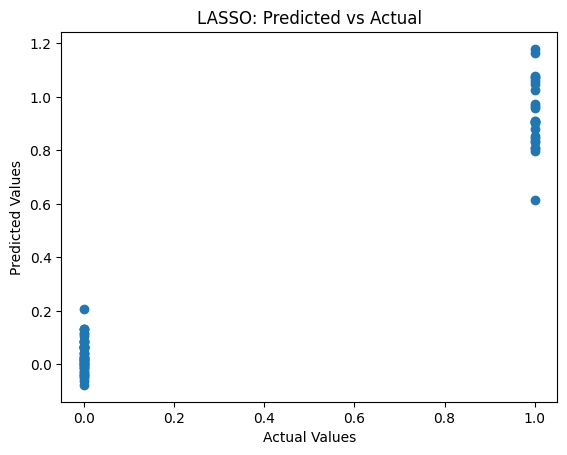


Optimal alpha: 129.75017431132844


In [19]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


lasso = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso.fit(X, y)


y_pred_lasso = lasso.predict(X)


mse_lasso = mean_squared_error(y, y_pred_lasso)
print("LASSO Training MSE:", mse_lasso)



coeffs = pd.Series(lasso.coef_, index=X.columns)


selected_genes = coeffs[coeffs != 0]

print("\nSelected genes:")
print(selected_genes)

print("\nNumber of selected genes:", len(selected_genes))
print("Number of discarded genes:", (coeffs == 0).sum())


plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LASSO: Predicted vs Actual")
plt.show()


print("\nOptimal alpha:", lasso.alpha_)

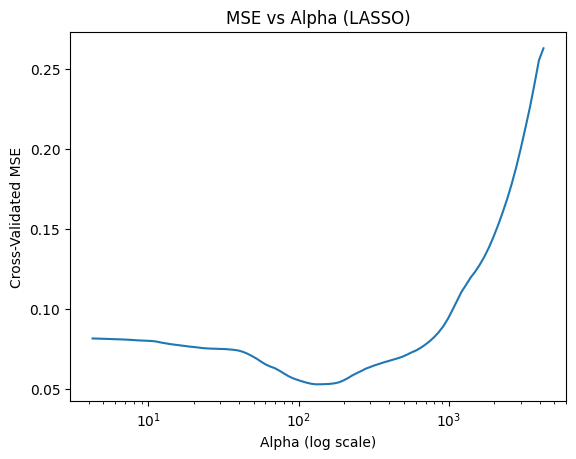

Optimal alpha: 129.75017431132844


In [20]:
import matplotlib.pyplot as plt
import numpy as np

alphas = lasso.alphas_


mse_path = np.mean(lasso.mse_path_, axis=1)


plt.plot(alphas, mse_path)
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-Validated MSE")
plt.title("MSE vs Alpha (LASSO)")
plt.show()


print("Optimal alpha:", lasso.alpha_)

5. For smaller values like between 1 and 30 , the Lasso model overfits and for larger values like 500 the model underfits.

6. Linear regression performs perfectly on the training set because the number of predictors is larger than the number of observations. This allows the model to fit the training data perfectly with a near zero training error. This can lead to overfitting. LASSO penalizes the magnitude of the coefficients which shrinks them towards zero. This reduces complexity and variance in the model and prevents overfitting, however LASSO may have a higher training error and leads to generalizations better for data that is not seen and leads to and improved predictive nature.

7. Regularization methods are useful in precision health because the data often has a lot of features and without regularization, models can overfit and make unreliable predictions. LASSO reduces complexity and prevents overfitting whie focusing on the important features.

8. The main risk is that LASSO may choose features that are not causal but appear important but are not. This may lead to incorrect conclusions and lead to a harmful treatment. These results could be unstable among small data sets. Overall, relying heavily on LASSO could lead to an ineffective or harmful treatment for patients.